# Belajar Analisis Sentimen - Dari Dasar

Notebook ini akan memandu kamu memahami cara kerja analisis sentimen step by step.

**Apa itu Analisis Sentimen?**
Teknik NLP (Natural Language Processing) untuk menentukan apakah suatu teks bernada **positif**, **negatif**, atau **netral**.

---
## Step 1: Persiapan Library

Kita akan pakai beberapa library:
- **re** → untuk preprocessing teks (regex)
- **scikit-learn** → untuk TF-IDF dan model ML
- **pandas, numpy** → manipulasi data
- **matplotlib, seaborn** → visualisasi

In [1]:
# Install library yang dibutuhkan (jalankan sekali)
!pip install scikit-learn textblob pandas numpy matplotlib seaborn

In [2]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

sns.set_style('whitegrid')
plt.rcParams['font.size'] = 12

print('Semua library berhasil di-import!')

Semua library berhasil di-import!


---
## Step 2: Siapkan Data

Kita mulai dengan dataset sederhana dulu supaya gampang dipahami.
Nanti bisa diganti dengan dataset yang lebih besar.

In [3]:
# Dataset contoh: review produk (lebih banyak data)
# Label: 1 = positif, -1 = negatif, 0 = netral

data = {
    'teks': [
        'Produk ini sangat bagus dan berkualitas',
        'Pelayanan cepat dan ramah sekali',
        'Saya sangat puas dengan hasilnya',
        'Barangnya keren sesuai deskripsi',
        'Luar biasa recommended banget',
        'Kualitas oke punya tidak mengecewakan',
        'Pengiriman super cepat packaging rapi',
        'Harga murah tapi kualitas mantap',
        'Sangat recommended akan beli lagi',
        'Top seller terbaik pokoknya',
        'Bagus banget produknya memuaskan',
        'Pelayanan memuaskan sangat profesional',
        'Kualitas premium harga terjangkau',
        'Packaging rapi barang aman sampai tujuan',
        'Seller responsif dan ramah sekali',
        'Produk jelek kualitas buruk sekali',
        'Pelayanan lambat dan tidak ramah',
        'Kecewa berat tidak sesuai foto',
        'Barangnya rusak saat sampai',
        'Sangat tidak puas mau refund',
        'Kualitas mengecewakan jangan beli',
        'Pengiriman lama banget parah',
        'Harga mahal tapi kualitas rendah',
        'Penipuan barang tidak dikirim',
        'Seller tidak bertanggung jawab',
        'Produk cacat tidak layak jual',
        'Pelayanan buruk tidak pernah dibalas',
        'Barang palsu tidak original',
        'Rugi beli di sini mengecewakan',
        'Kualitas hancur uang terbuang',
        'Produk biasa saja tidak istimewa',
        'Standar saja seperti biasa',
        'Lumayan oke untuk harganya',
        'Barang sampai dengan selamat',
        'Sesuai dengan yang dipesan',
        'Biasa saja tidak ada yang spesial',
        'Cukup oke tapi bukan yang terbaik',
        'Harga pas kualitas standar',
        'Pengiriman normal tidak cepat tidak lambat',
        'Produk sesuai deskripsi tidak lebih tidak kurang',
    ],
    'label': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
              1, 1, 1, 1, 1,
              -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
              -1, -1, -1, -1, -1,
              0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
}

df = pd.DataFrame(data)
print(f'Total data: {len(df)}')
print(f'\nDistribusi label:')
print(df['label'].value_counts().sort_index().map({1: 'Positif', -1: 'Negatif', 0: 'Netral'}))
df

Total data: 40

Distribusi label:
label
-1    NaN
 0    NaN
 1    NaN
Name: count, dtype: object


,teks,label
0,Produk ini sangat bagus dan berkualitas,1
1,Pelayanan cepat dan ramah sekali,1
2,Saya sangat puas dengan hasilnya,1
3,Barangnya keren sesuai deskripsi,1
4,Luar biasa recommended banget,1
5,Kualitas oke punya tidak mengecewakan,1
6,Pengiriman super cepat packaging rapi,1
7,Harga murah tapi kualitas mantap,1
8,Sangat recommended akan beli lagi,1
9,Top seller terbaik pokoknya,1


---
## Step 3: Preprocessing Teks

Sebelum teks bisa diproses model ML, kita harus bersihkan dulu:

1. **Case folding** → ubah ke huruf kecil
2. **Cleaning** → hapus angka, tanda baca, URL
3. **Stopword removal** → hapus kata umum yang tidak bermakna (yang, dan, di, ke, dll)

> Stemming dinonaktifkan karena untuk dataset kecil, stemming sederhana bisa merusak kata (contoh: "kecewa" → "cewa"). Nanti kalau pakai library seperti Sastrawi, hasilnya lebih baik.

In [4]:
# Daftar stopwords bahasa Indonesia (manual, tanpa sastrawi)
STOPWORDS_ID = set([
    'yang', 'dan', 'di', 'ke', 'dari', 'untuk', 'dengan', 'pada', 'adalah',
    'ini', 'itu', 'tidak', 'tak', 'juga', 'sudah', 'akan', 'bisa', 'telah',
    'saya', 'kami', 'kita', 'mereka', 'dia', 'ia', 'anda', 'kamu', 'kalian',
    'ada', 'sangat', 'saja', 'lagi', 'lah', 'nya', 'si', 'sih', 'dong',
    'deh', 'tuh', 'kan', 'kok', 'lho', 'nih', 'nah', 'ya', 'gak', 'nggak',
    'emang', 'cuma', 'tapi', 'kalau', 'kalo', 'soal', 'oleh', 'saat',
    'atau', 'agar', 'supaya', 'biar', 'belum', 'masih', 'hanya',
    'the', 'a', 'an', 'is', 'are', 'was', 'were', 'be', 'been', 'being',
    'have', 'has', 'had', 'do', 'does', 'did', 'will', 'would', 'could',
    'should', 'may', 'might', 'must', 'shall', 'can', 'need', 'dare',
    'ought', 'used', 'to', 'of', 'in', 'for', 'on', 'with', 'at', 'by',
    'from', 'as', 'into', 'through', 'during', 'before', 'after', 'above',
    'below', 'between', 'out', 'off', 'over', 'under', 'again', 'further',
    'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how', 'all',
    'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such', 'no',
    'not', 'only', 'own', 'same', 'so', 'than', 'too', 'very',
])

# Stemming dinonaktifkan karena terlalu agresif untuk dataset kecil
# (contoh: "kecewa" jadi "cewa", "penipuan" jadi "nipuan")
# Untuk demo, kita skip stemming dan langsung pakai kata aslinya

def preprocess(teks):
    teks = teks.lower()
    teks = re.sub(r'[^a-z\s]', '', teks)
    teks = re.sub(r'\s+', ' ', teks).strip()
    kata_kata = teks.split()
    kata_kata = [k for k in kata_kata if k not in STOPWORDS_ID]
    teks = ' '.join(kata_kata)
    return teks

df['teks_bersih'] = df['teks'].apply(preprocess)

comparison = df[['teks', 'teks_bersih']].copy()
comparison.columns = ['Sebelum', 'Sesudah']
comparison

,Sebelum,Sesudah
0,Produk ini sangat bagus dan berkualitas,produk bagus berkualitas
1,Pelayanan cepat dan ramah sekali,pelayanan cepat ramah sekali
2,Saya sangat puas dengan hasilnya,puas hasilnya
3,Barangnya keren sesuai deskripsi,barangnya keren sesuai deskripsi
4,Luar biasa recommended banget,luar biasa recommended banget
5,Kualitas oke punya tidak mengecewakan,kualitas oke punya mengecewakan
6,Pengiriman super cepat packaging rapi,pengiriman super cepat packaging rapi
7,Harga murah tapi kualitas mantap,harga murah kualitas mantap
8,Sangat recommended akan beli lagi,recommended beli
9,Top seller terbaik pokoknya,top seller terbaik pokoknya


In [5]:
# Bag of Words
bow = CountVectorizer()
X_bow = bow.fit_transform(df['teks_bersih'])

print(f'Jumlah kata unik (vocabulary): {len(bow.get_feature_names_out())}')
print(f'Ukuran matrix: {X_bow.shape}')
print(f'\nContoh vocabulary (20 kata pertama):')
print(bow.get_feature_names_out()[:20])

# Tampilkan sebagai DataFrame supaya mudah dibaca
df_bow = pd.DataFrame(X_bow.toarray(), columns=bow.get_feature_names_out())
print(f'\nMatrix Bag of Words:')
df_bow.head(10)

Jumlah kata unik (vocabulary): 87
Ukuran matrix: (40, 87)

Contoh vocabulary (20 kata pertama):
['aman' 'bagus' 'banget' 'barang' 'barangnya' 'beli' 'berat' 'berkualitas'
 'bertanggung' 'biasa' 'bukan' 'buruk' 'cacat' 'cepat' 'cukup' 'deskripsi'
 'dibalas' 'dikirim' 'dipesan' 'foto']

Matrix Bag of Words:


,aman,bagus,banget,barang,barangnya,beli,berat,berkualitas,bertanggung,biasa,...,sini,spesial,standar,super,terbaik,terbuang,terjangkau,top,tujuan,uang
0,0,1,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,1,0,0


### Metode 2: TF-IDF (Term Frequency - Inverse Document Frequency)

Lebih pintar dari BoW. Kata yang sering muncul di **semua** dokumen dapat bobot rendah.
Kata yang khas di satu dokumen saja dapat bobot tinggi.

Rumus:
- **TF** = seberapa sering kata muncul di dokumen ini
- **IDF** = seberapa jarang kata muncul di semua dokumen
- **TF-IDF** = TF × IDF

In [6]:
# TF-IDF
tfidf = TfidfVectorizer()
X_tfidf = tfidf.fit_transform(df['teks_bersih'])

print(f'Ukuran matrix TF-IDF: {X_tfidf.shape}')

df_tfidf = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())
print(f'\nMatrix TF-IDF (nilai lebih halus, antara 0-1):')
df_tfidf.head(10)

Ukuran matrix TF-IDF: (40, 87)

Matrix TF-IDF (nilai lebih halus, antara 0-1):


,aman,bagus,banget,barang,barangnya,beli,berat,berkualitas,bertanggung,biasa,...,sini,spesial,standar,super,terbaik,terbuang,terjangkau,top,tujuan,uang
0,0.0,0.588217,0.000000,0.0,0.000000,0.000000,0.0,0.654193,0.0,0.000000,...,0.0,0.0,0.0,0.00000,0.00000,0.0,0.0,0.000000,0.0,0.0
1,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.00000,0.00000,0.0,0.0,0.000000,0.0,0.0
2,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.00000,0.00000,0.0,0.0,0.000000,0.0,0.0
3,0.0,0.000000,0.000000,0.0,0.501617,0.000000,0.0,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.00000,0.00000,0.0,0.0,0.000000,0.0,0.0
4,0.0,0.000000,0.470839,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.439263,...,0.0,0.0,0.0,0.00000,0.00000,0.0,0.0,0.000000,0.0,0.0
5,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.00000,0.00000,0.0,0.0,0.000000,0.0,0.0
6,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.50083,0.00000,0.0,0.0,0.000000,0.0,0.0
7,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.00000,0.00000,0.0,0.0,0.000000,0.0,0.0
8,0.0,0.000000,0.000000,0.0,0.000000,0.677223,0.0,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.00000,0.00000,0.0,0.0,0.000000,0.0,0.0
9,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.00000,0.48107,0.0,0.0,0.535029,0.0,0.0


In [7]:
# Lihat kata dengan bobot TF-IDF tertinggi di dokumen pertama
doc_idx = 0
feature_names = tfidf.get_feature_names_out()
scores = X_tfidf[doc_idx].toarray().flatten()

top_kata = sorted(zip(feature_names, scores), key=lambda x: x[1], reverse=True)[:10]

print(f'Teks: "{df.iloc[doc_idx]["teks"]}"')
print(f'\nKata dengan bobot TF-IDF tertinggi:')
for kata, skor in top_kata:
    print(f'  {kata:20s} → {skor:.4f}')

Teks: "Produk ini sangat bagus dan berkualitas"

Kata dengan bobot TF-IDF tertinggi:
  berkualitas          → 0.6542
  bagus                → 0.5882
  produk               → 0.4754
  aman                 → 0.0000
  banget               → 0.0000
  barang               → 0.0000
  barangnya            → 0.0000
  beli                 → 0.0000
  berat                → 0.0000
  bertanggung          → 0.0000


---
## Step 5: Latih Model ML (Naive Bayes)

Naive Bayes adalah model klasifikasi berbasis probabilitas.
Simpel, cepat, dan cocok untuk klasifikasi teks.

Konsepnya: berdasarkan kata-kata yang muncul, berapa probabilitas teks ini positif vs negatif?

In [8]:
# Split data: training (80%) dan testing (20%)
# Pakai stratify supaya proporsi tiap kelas seimbang di train dan test
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, df['label'], test_size=0.2, random_state=42, stratify=df['label']
)

print(f'Data training: {X_train.shape[0]}')
print(f'Data testing:  {X_test.shape[0]}')
print(f'\nDistribusi kelas di training: {dict(y_train.value_counts())}')
print(f'Distribusi kelas di testing:  {dict(y_test.value_counts())}')

# Latih model Naive Bayes
model = MultinomialNB()
model.fit(X_train, y_train)

# Prediksi data testing
y_pred = model.predict(X_test)

# Evaluasi
print(f'\nAkurasi: {accuracy_score(y_test, y_pred):.2%}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Negatif', 'Netral', 'Positif'], zero_division=0))

Data training: 32
Data testing:  8

Distribusi kelas di training: {-1: np.int64(12), 1: np.int64(12), 0: np.int64(8)}
Distribusi kelas di testing:  {1: np.int64(3), -1: np.int64(3), 0: np.int64(2)}

Akurasi: 25.00%

Classification Report:
              precision    recall  f1-score   support

     Negatif       0.33      0.33      0.33         3
      Netral       0.00      0.00      0.00         2
     Positif       0.20      0.33      0.25         3

    accuracy                           0.25         8
   macro avg       0.18      0.22      0.19         8
weighted avg       0.20      0.25      0.22         8



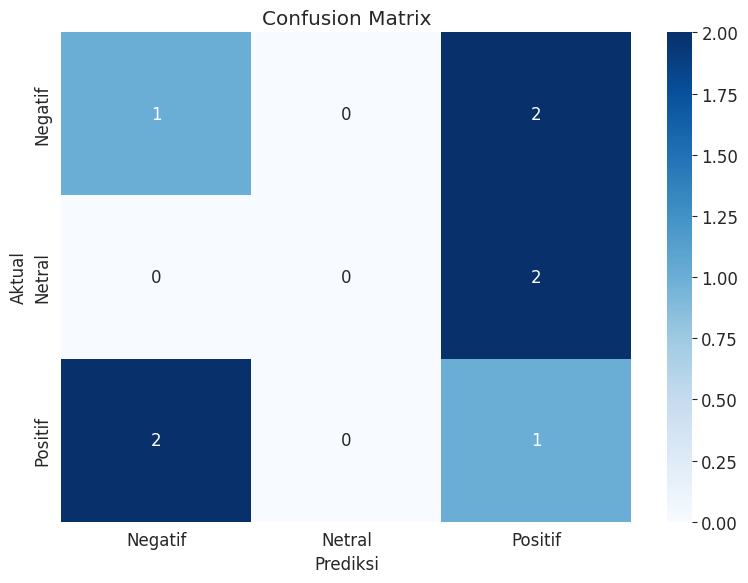

In [9]:
# Confusion Matrix - visualisasi performa model
cm = confusion_matrix(y_test, y_pred, labels=[-1, 0, 1])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negatif', 'Netral', 'Positif'],
            yticklabels=['Negatif', 'Netral', 'Positif'])
plt.title('Confusion Matrix')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.show()

---
## Step 6: Uji dengan Teks Baru

Sekarang kita bisa pakai model yang sudah dilatih untuk menganalisis sentimen teks baru.

In [10]:
def prediksi_sentimen(teks, model, tfidf_vectorizer):
    # Preprocessing
    teks_bersih = preprocess(teks)
    
    # Transform ke TF-IDF
    X = tfidf_vectorizer.transform([teks_bersih])
    
    # Prediksi
    label = model.predict(X)[0]
    proba = model.predict_proba(X)[0]
    
    label_map = {-1: 'NEGATIF', 0: 'NETRAL', 1: 'POSITIF'}
    
    print(f'Teks:     "{teks}"')
    print(f'Bersih:   "{teks_bersih}"')
    print(f'Sentimen: {label_map[label]}')
    print(f'\nProbabilitas:')
    for i, (lbl, prob) in enumerate(zip([-1, 0, 1], proba)):
        bar = '█' * int(prob * 30)
        print(f'  {label_map[lbl]:10s}: {prob:.2%} {bar}')
    print()

# Coba dengan kalimat baru
kalimat_baru = [
    'Barangnya bagus banget, saya suka!',
    'Pelayanan jelek, lama banget nunggunya',
    'Barang sudah sampai, sesuai pesanan',
    'Kecewa, kualitasnya tidak sesuai harapan',
    'Lumayan lah, tidak terlalu bagus tidak terlalu jelek',
]

for kalimat in kalimat_baru:
    prediksi_sentimen(kalimat, model, tfidf)

Teks:     "Barangnya bagus banget, saya suka!"
Bersih:   "barangnya bagus banget suka"
Sentimen: POSITIF

Probabilitas:
  NEGATIF   : 23.90% ███████
  NETRAL    : 18.56% █████
  POSITIF   : 57.54% █████████████████

Teks:     "Pelayanan jelek, lama banget nunggunya"
Bersih:   "pelayanan jelek lama banget nunggunya"
Sentimen: NEGATIF

Probabilitas:
  NEGATIF   : 46.04% █████████████
  NETRAL    : 21.66% ██████
  POSITIF   : 32.29% █████████

Teks:     "Barang sudah sampai, sesuai pesanan"
Bersih:   "barang sampai sesuai pesanan"
Sentimen: POSITIF

Probabilitas:
  NEGATIF   : 30.64% █████████
  NETRAL    : 33.85% ██████████
  POSITIF   : 35.51% ██████████

Teks:     "Kecewa, kualitasnya tidak sesuai harapan"
Bersih:   "kecewa kualitasnya sesuai harapan"
Sentimen: NEGATIF

Probabilitas:
  NEGATIF   : 43.33% █████████████
  NETRAL    : 25.40% ███████
  POSITIF   : 31.26% █████████

Teks:     "Lumayan lah, tidak terlalu bagus tidak terlalu jelek"
Bersih:   "lumayan terlalu bagus terlalu jel

---
## Step 7: Analisis Kata Paling Berpengaruh

Kata mana yang paling berkontribusi ke sentimen positif atau negatif?

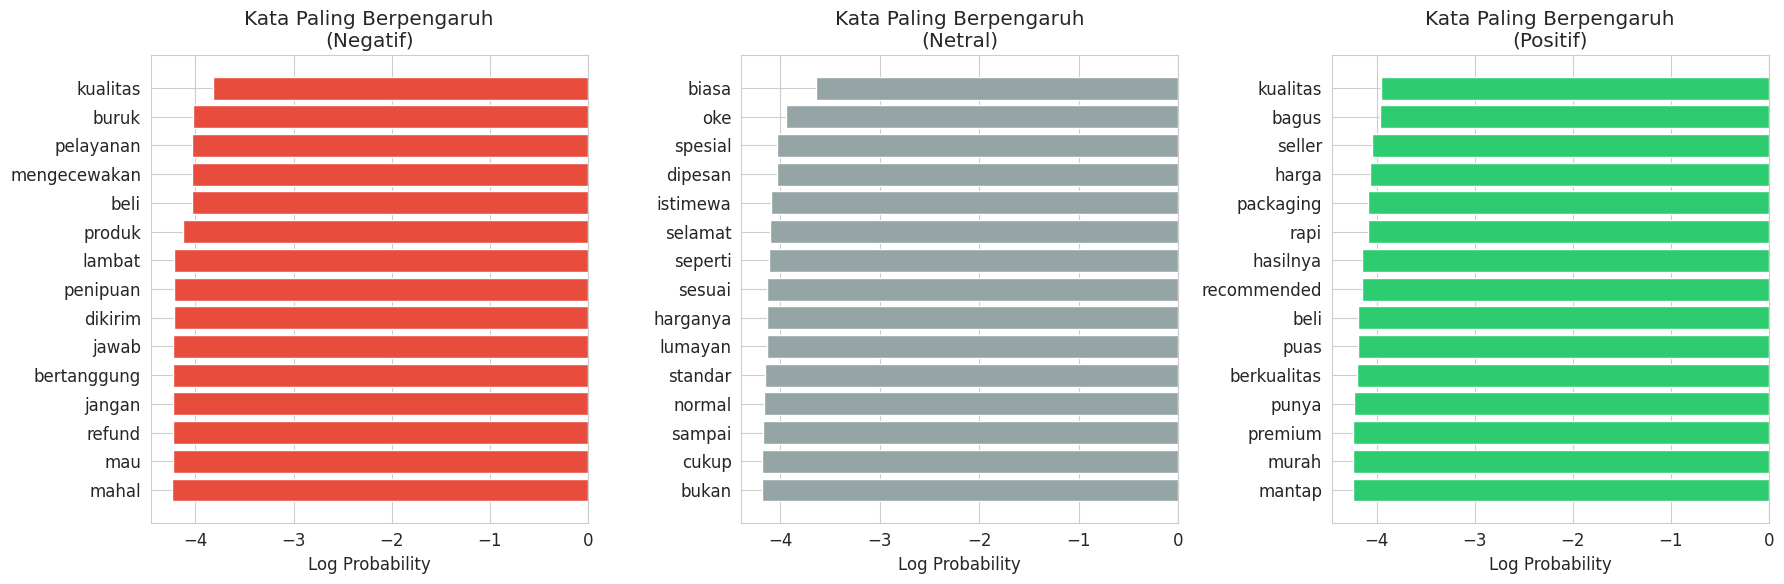

In [11]:
# Ekstrak bobot kata dari model Naive Bayes
feature_names = tfidf.get_feature_names_out()

# log_probabilities dari Naive Bayes
log_probs = model.feature_log_prob_

# Untuk setiap kelas, cari kata dengan bobot tertinggi
label_map = {-1: 'Negatif', 0: 'Netral', 1: 'Positif'}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, (label, name) in enumerate(zip([-1, 0, 1], ['Negatif', 'Netral', 'Positif'])):
    class_idx = list(model.classes_).index(label)
    top_indices = log_probs[class_idx].argsort()[-15:][::-1]
    top_words = feature_names[top_indices]
    top_scores = log_probs[class_idx][top_indices]
    
    colors = ['#e74c3c' if label == -1 else '#95a5a6' if label == 0 else '#2ecc71'] * 15
    axes[idx].barh(range(15), top_scores, color=colors)
    axes[idx].set_yticks(range(15))
    axes[idx].set_yticklabels(top_words)
    axes[idx].set_title(f'Kata Paling Berpengaruh\n({name})')
    axes[idx].set_xlabel('Log Probability')
    axes[idx].invert_yaxis()

plt.tight_layout()
plt.show()

---
## Step 8: Perbandingan dengan Model Lain

Coba bandingkan Naive Bayes dengan model lain.

Naive Bayes               → Akurasi: 25.00%
Logistic Regression       → Akurasi: 25.00%
SVM (Linear)              → Akurasi: 25.00%
Random Forest             → Akurasi: 12.50%


/tmp/ipykernel_10494/2579718467.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_results, x='Akurasi', y='Model', palette='viridis')


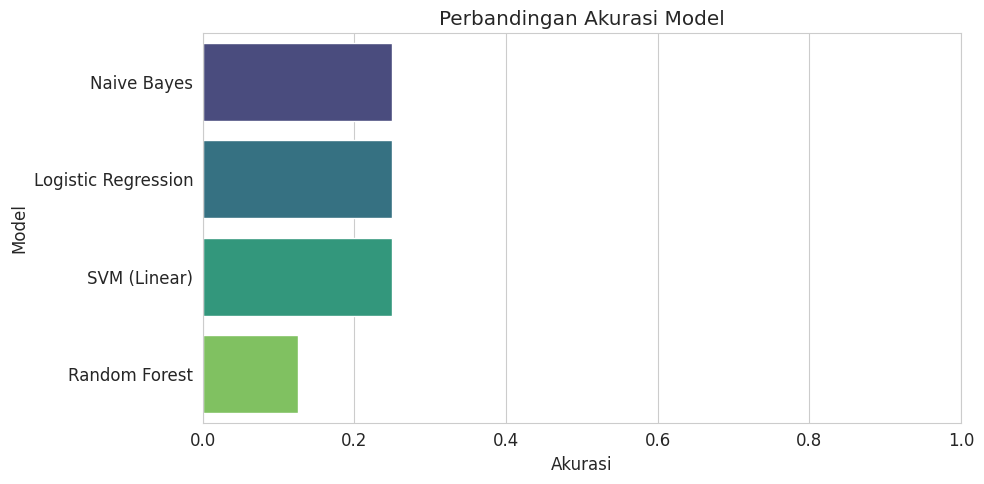

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

models = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'SVM (Linear)': LinearSVC(max_iter=10000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
}

results = []

for nama, mdl in models.items():
    mdl.fit(X_train, y_train)
    y_pred = mdl.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append({'Model': nama, 'Akurasi': acc})
    print(f'{nama:25s} → Akurasi: {acc:.2%}')

# Visualisasi perbandingan
df_results = pd.DataFrame(results)
plt.figure(figsize=(10, 5))
sns.barplot(data=df_results, x='Akurasi', y='Model', palette='viridis')
plt.title('Perbandingan Akurasi Model')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

---
## Ringkasan: Alur Analisis Sentimen

```
Teks Mentah
    ↓
Preprocessing (case fold, cleaning, stopword, stemming)
    ↓
Feature Extraction (BoW / TF-IDF / Word Embedding)
    ↓
Model ML (Naive Bayes / SVM / LSTM / BERT)
    ↓
Prediksi Sentimen (Positif / Negatif / Netral)
```

## Langkah Selanjutnya

- Coba dengan dataset yang lebih besar (misal: review dari Tokopedia/Shopee)
- Eksperimen dengan Word Embedding (Word2Vec, GloVe, FastText)
- Coba Deep Learning (LSTM, BERT) untuk akurasi lebih tinggi
- Deploy jadi web app (Flask/FastAPI + React)